# Crypto Intelligence Dashboard: The Full Forensic Suite

## Strategic Objective
This notebook serves as the final prototype for Looker Studio. It combines statistical validation with Machine Learning signals to explain market exhaustion.

---

In [13]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv
from datetime import datetime

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

load_dotenv('.env')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [15, 7]
print(f"[SUCCESS] Working Directory: {os.getcwd()}")

[SUCCESS] Working Directory: /Users/charlie/ai_projects/portafolio/crypto-ml-predictor


## 1. Unified Data Ingestion

In [14]:
project_id = os.getenv('GCP_PROJECT_ID')
dataset_id = os.getenv('GCP_DATASET_ID')
client = bigquery.Client(project=project_id)

query = f"SELECT * FROM `{project_id}.{dataset_id}.vw_looker_master_intelligence` ORDER BY ds ASC"
df = client.query(query).to_dataframe()
df['ds'] = pd.to_datetime(df['ds'])

if 'ml_volume_zscore' not in df.columns and 'zscore_30d' in df.columns:
    df['ml_volume_zscore'] = df['zscore_30d']

print(f"[SUCCESS] {len(df)} records loaded.")

/Users/charlie/ai_projects/portafolio/crypto-ml-predictor/venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


[SUCCESS] 1970 records loaded.


## 2. Visual 1: Price & ML Signal Overlay

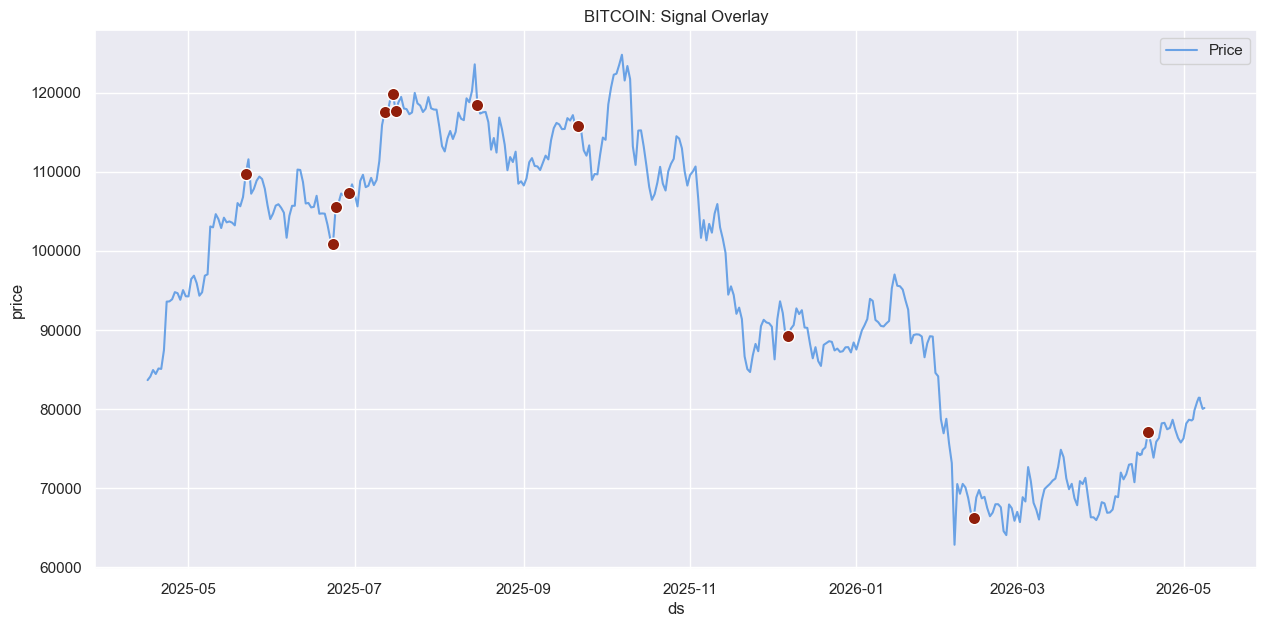

In [15]:
asset_id = 'bitcoin'
subset = df[df['id'] == asset_id].copy()
fig, ax = plt.subplots()
sns.lineplot(data=subset, x='ds', y='price', ax=ax, label='Price', color='#4A90E2', alpha=0.8)
bullish = subset[subset['ml_prediction'] == 1]
ax.scatter(bullish['ds'], bullish['price'], color="#911F0B", label='ML Signal', s=80, edgecolor='white', zorder=5)
plt.title(f"{asset_id.upper()}: Signal Overlay")
plt.show()

## 3. Visual 2: The Pulse (Price vs Volume Shock)

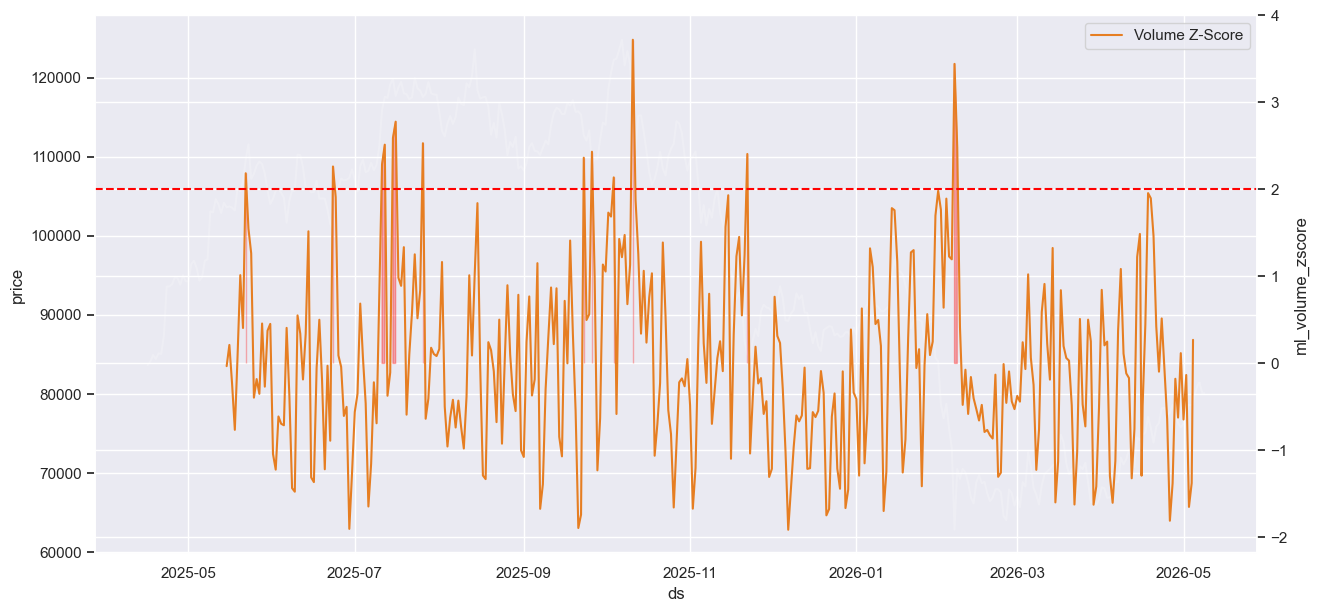

In [16]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
sns.lineplot(data=subset, x='ds', y='price', ax=ax1, color='white', alpha=0.2)
sns.lineplot(data=subset, x='ds', y='ml_volume_zscore', ax=ax2, color='#E67E22', label='Volume Z-Score')
ax2.axhline(2.0, color='red', linestyle='--')
ax2.fill_between(subset['ds'], 0, subset['ml_volume_zscore'], where=(subset['ml_volume_zscore'] > 2), color='red', alpha=0.3)
plt.show()

## 4. Visual 3: Macro Monthly Risk

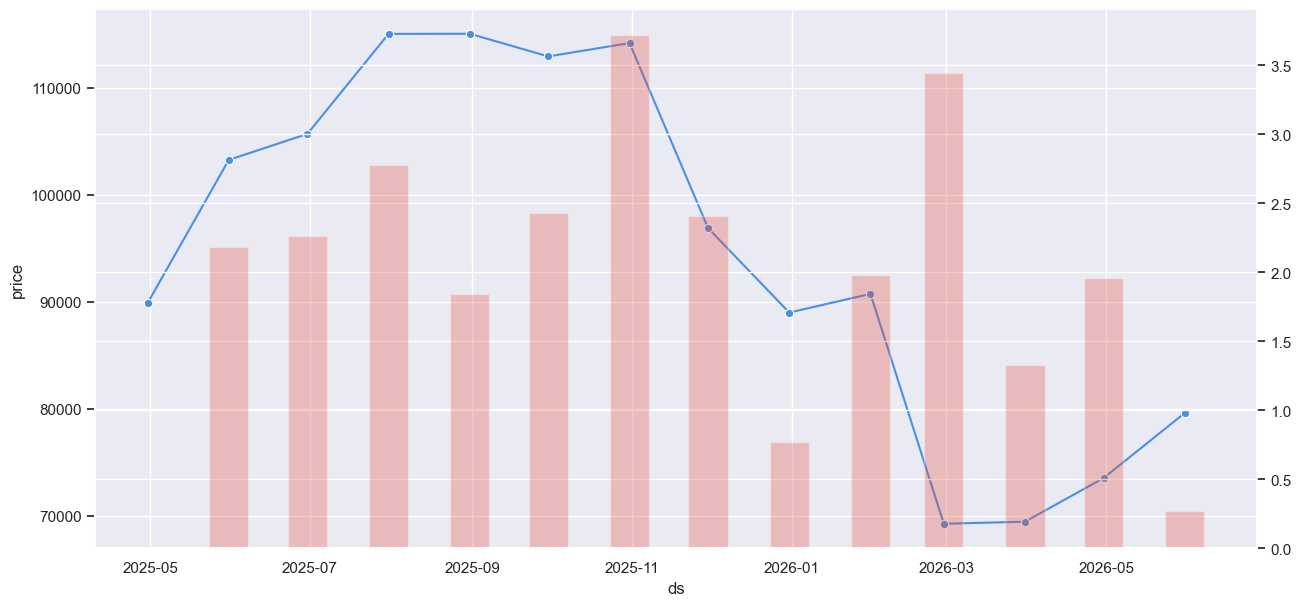

In [17]:
monthly_df = subset.resample('ME', on='ds').agg({'price': 'mean', 'ml_volume_zscore': 'max'}).reset_index()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
sns.lineplot(data=monthly_df, x='ds', y='price', ax=ax1, marker='o', color='#4A90E2')
ax2.bar(monthly_df['ds'], monthly_df['ml_volume_zscore'], width=15, color='#E74C3C', alpha=0.3)
plt.show()

## 5. Visual 4: Forensic Tsunami Autopsy

In [18]:
top_10 = subset.sort_values('ml_volume_zscore', ascending=False).head(20).copy()
print("=== TOP 10 SHOCK OUTCOMES ===")
display(top_10[['ds', 'price', 'ml_volume_zscore', 'return_t30', 'ml_probability']].sort_values('ds'))

=== TOP 10 SHOCK OUTCOMES ===


,ds,price,ml_volume_zscore,return_t30,ml_probability
181,2025-05-22 00:00:00+00:00,109665.863716,2.186257,-0.058138,0.579910
343,2025-06-23 00:00:00+00:00,100852.582646,2.264035,0.189417,0.553348
346,2025-06-24 00:00:00+00:00,105511.624379,1.912580,0.124322,0.507234
432,2025-07-11 00:00:00+00:00,115879.650301,2.287432,0.005440,0.356238
438,2025-07-12 00:00:00+00:00,117571.025100,2.514922,0.014424,0.513304
452,2025-07-15 00:00:00+00:00,119833.674467,2.591770,0.031104,0.505583
458,2025-07-16 00:00:00+00:00,117678.194934,2.779252,0.006181,0.507671
505,2025-07-26 00:00:00+00:00,117540.808371,2.531534,-0.035233,0.367610
801,2025-09-23 00:00:00+00:00,112696.741017,2.365187,-0.045062,0.355784
815,2025-09-26 00:00:00+00:00,108963.530136,2.433748,0.024382,0.163616


## 6. Visual 5: Unified Forensic Impact Study

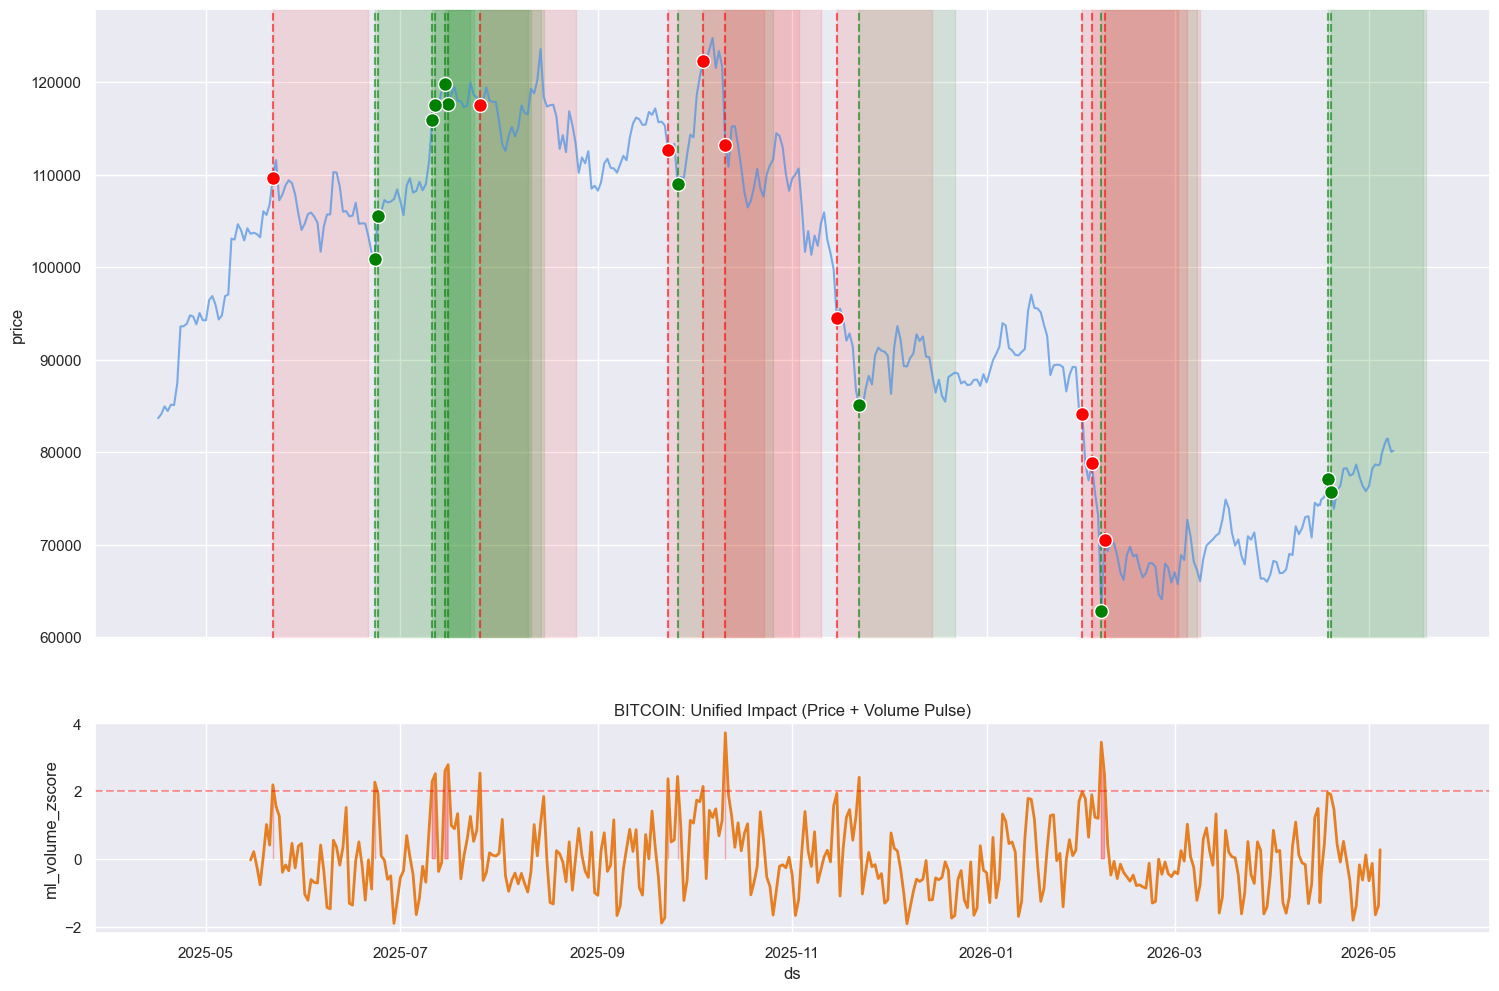

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
sns.lineplot(data=subset, x='ds', y='price', ax=ax1, color='#4A90E2', alpha=0.7)

for idx, row in top_10.iterrows():
    impact_color = 'red' if row['return_t30'] < 0 else 'green'
    ax1.axvline(row['ds'], color=impact_color, linestyle='--', alpha=0.6)
    ax1.axvspan(row['ds'], row['ds'] + pd.Timedelta(days=30), color=impact_color, alpha=0.1)
    # THE MISSING FIX: Adding the marker points back
    ax1.scatter(row['ds'], row['price'], color=impact_color, s=100, zorder=10, edgecolor='white')

sns.lineplot(data=subset, x='ds', y='ml_volume_zscore', ax=ax2, color='#E67E22', linewidth=2)
ax2.axhline(2.0, color='red', linestyle='--', alpha=0.4)
ax2.fill_between(subset['ds'], 0, subset['ml_volume_zscore'], where=(subset['ml_volume_zscore'] > 2), color='red', alpha=0.3)

plt.title(f"{asset_id.upper()}: Unified Impact (Price + Volume Pulse)")
plt.show()